# 08 — Optuna tuning ของ XGBoost (CMF)

ผลทั้งหมดมาจาก `python -m src.tune --trials 100` ใช้เฉพาะข้อมูล 2023–2024 **ไม่ได้โหลดข้อมูลปี 2025**
notebook นี้อ่าน study (`source_code/models/optuna_cmf_xgb_v1.db`) และตารางผลใน `docs/` มาวิเคราะห์ต่อ

**กฎที่ประกาศไว้ในแผนวัน 8 ก่อนรัน:**
- **Objective:** MAE บนสเกล UVI ของ XGBoost ที่ทำนาย CMF_UVI (weight `uvi_clear²`) เฉลี่ยบน **fold 3–5** ของ TimeSeriesSplit(5, gap 12) ใน 2023–2024 (fold 3–5 ฝึกด้วยข้อมูลอย่างน้อย 12 เดือน)
- TPE (seed 42) + MedianPruner ระดับ fold, 100 trials, log recall ระดับ**สูงมาก**/**รุนแรงมาก**ของทุก trial
- **กฎรับ params:** trial ที่ MAE ต่ำสุดจะแทน `XGB_PARAMS` ก็ต่อเมื่อ (1) CV MAE ดีกว่า params เดิมบน fold เดียวกัน **เกิน 0.01 UVI** และ (2) ค่าเฉลี่ย recall ระดับสูงมาก+รุนแรงมาก **ลดลงไม่เกิน 0.03** ถ้าไม่ผ่านให้ใช้ params เดิม

⚠️ หลังวัน 8 ตัวเลข dev 2024 มี **optimistic bias** เพราะ fold 3–5 ที่ใช้ tune อยู่ในปี 2024 ตัวเลขที่ไม่ลำเอียงคือ test 2025 ในวัน 10

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve().parents[1]  # notebooks/ -> source_code/ -> Final-Project/
sys.path.insert(0, str(ROOT / "source_code"))

FIG_DIR = ROOT / "docs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# reference palette (dataviz skill): fixed categorical order, recessive axes
C_OM, C_NASA, C_THIRD = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK2, MUTED, GRID = "#0b0b0b", "#52514e", "#898781", "#e6e5e1"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": MUTED, "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "lines.linewidth": 2, "legend.frameon": False, "figure.dpi": 100,
})


def save(fig, name):
    """Save a figure to docs/figures at 150 dpi."""
    fig.savefig(FIG_DIR / name, dpi=150, bbox_inches="tight")

In [2]:
import json

import optuna

from src.train_cmf import MODEL_DIR
from src.tune import BEST_PARAMS_PATH, STORAGE_PATH, STUDY_NAME

docs = ROOT / "docs"
trials = pd.read_csv(docs / "optuna_trials.csv")
best = json.loads(BEST_PARAMS_PATH.read_text(encoding="utf-8"))
dev = pd.read_csv(docs / "tuning_dev_2024.csv")
study = optuna.load_study(study_name=STUDY_NAME, storage=f"sqlite:///{STORAGE_PATH.as_posix()}")
default_mae, default_rec = best["default"]["uvi_mae"], best["default"]["alert_recall"]
print(trials["state"].value_counts().to_string())
print(f"default: CV MAE {default_mae:.4f}, alert recall {default_rec:.3f}")
print(f"best trial #{best['best_trial']['number']}: CV MAE {best['best_trial']['uvi_mae']:.4f}, "
      f"alert recall {best['best_trial']['alert_recall']:.3f}")
print("accepted:", best["accepted"], "|", best["reason"])

state
PRUNED      58
COMPLETE    42
default: CV MAE 0.4579, alert recall 0.438
best trial #50: CV MAE 0.4466, alert recall 0.443
accepted: True | MAE gain +0.0113 (need > 0.01) -> ok; alert-recall drop -0.0054 (max 0.03) -> ok


## 1. Optimization history (CV MAE fold 3–5)

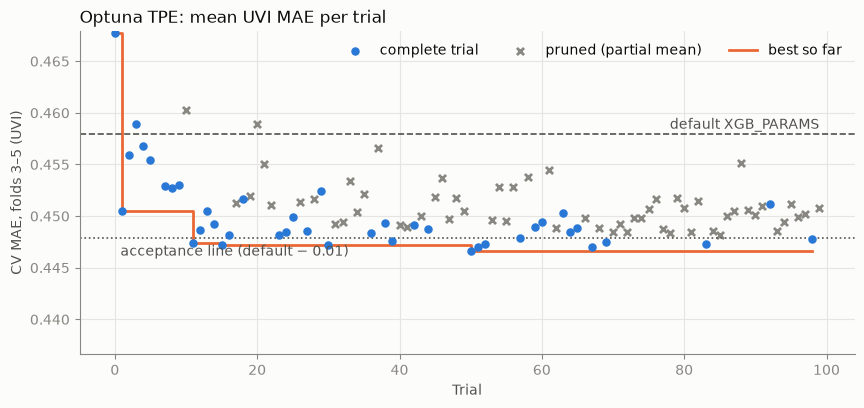

In [3]:
done = trials[trials["state"] == "COMPLETE"].sort_values("number")
pruned = trials[trials["state"] == "PRUNED"]
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.scatter(done["number"], done["value"], s=26, color=C_OM, label="complete trial", zorder=3)
# a pruned trial has no final value: plot its last reported running mean
fold_cols = [c for c in trials.columns if c.startswith("user_attrs_fold") and c.endswith("uvi_mae")]
pr_val = pruned[fold_cols].mean(axis=1)
ax.scatter(pruned["number"], pr_val, s=26, marker="x", color=MUTED, label="pruned (partial mean)", zorder=2)
ax.step(done["number"], done["value"].cummin(), where="post", color=C_NASA, label="best so far")
ax.axhline(default_mae, color=INK2, ls="--", lw=1.2)
ax.axhline(default_mae - 0.01, color=INK2, ls=":", lw=1.2)
ax.annotate("default XGB_PARAMS", (trials["number"].max(), default_mae), textcoords="offset points",
            xytext=(0, 4), ha="right", color=INK2)
ax.annotate("acceptance line (default − 0.01)", (0, default_mae - 0.01),
            textcoords="offset points", xytext=(4, -13), ha="left", color=INK2)
top = np.nanpercentile(np.r_[done["value"], pr_val], 95)
ax.set_ylim(done["value"].min() - 0.01, max(top, default_mae) + 0.01)
ax.set_xlabel("Trial")
ax.set_ylabel("CV MAE, folds 3–5 (UVI)")
ax.set_title("Optuna TPE: mean UVI MAE per trial", loc="left")
ax.legend(loc="upper right", ncol=3)
save(fig, "optuna_history.png")

## 2. MAE กับ recall ระดับเตือนของทุก trial

พื้นที่แรเงาคือโซนที่ผ่านกฎรับ params (MAE ต่ำกว่า default เกิน 0.01 **และ** recall ลดลงไม่เกิน 0.03)

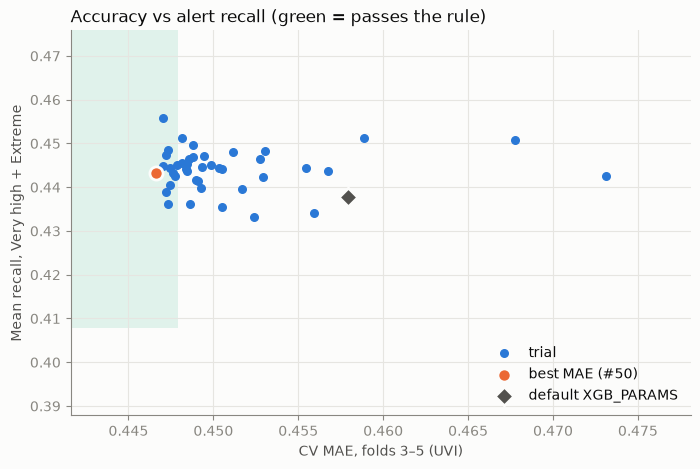

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
x0, x1 = done["value"].min() - 0.005, done["value"].max() + 0.005
y0, y1 = done["user_attrs_alert_recall"].min() - 0.02, done["user_attrs_alert_recall"].max() + 0.02
y0, y1 = min(y0, default_rec - 0.05), max(y1, default_rec + 0.02)
ax.fill_between([x0, default_mae - 0.01], default_rec - 0.03, 1.0, color=C_THIRD, alpha=0.12, lw=0)
ax.scatter(done["value"], done["user_attrs_alert_recall"], s=30, color=C_OM, label="trial", zorder=3)
b = best["best_trial"]
ax.scatter([b["uvi_mae"]], [b["alert_recall"]], s=90, color=C_NASA, edgecolor="#fcfcfb", lw=2,
           label=f"best MAE (#{b['number']})", zorder=4)
ax.scatter([default_mae], [default_rec], s=90, marker="D", color=INK2, edgecolor="#fcfcfb", lw=2,
           label="default XGB_PARAMS", zorder=4)
ax.set_xlim(x0, max(x1, default_mae + 0.005))
ax.set_ylim(y0, y1)
ax.set_xlabel("CV MAE, folds 3–5 (UVI)")
ax.set_ylabel("Mean recall, Very high + Extreme")
ax.set_title("Accuracy vs alert recall (green = passes the rule)", loc="left")
ax.legend(loc="lower right")
save(fig, "optuna_mae_recall.png")

In [5]:
cols = ["number", "value", "user_attrs_alert_recall", "user_attrs_recall_Very high",
        "user_attrs_recall_Extreme"] + [c for c in trials.columns if c.startswith("params_")]
done.sort_values("value")[cols].head(10).rename(columns=lambda c: c.replace("user_attrs_", "")).round(4)

,number,value,alert_recall,recall_Very high,recall_Extreme,params_colsample_bytree,params_gamma,params_learning_rate,params_max_depth,params_min_child_weight,params_n_estimators,params_reg_alpha,params_reg_lambda,params_subsample
50,50,0.4466,0.4433,0.8070,0.0795,0.5249,0.0000,0.0109,10,8.8096,850,0.0004,0.0025,0.8763
51,51,0.4470,0.4558,0.8188,0.0928,0.4899,0.0000,0.0102,8,11.2034,850,0.0004,0.0039,0.8872
67,67,0.4470,0.4449,0.8102,0.0795,0.5133,0.0001,0.0110,9,7.9717,800,0.0002,0.0047,0.8919
30,30,0.4472,0.4473,0.8151,0.0795,0.4374,0.0000,0.0120,9,11.2884,900,0.0012,0.0019,0.9901
15,15,0.4472,0.4390,0.7984,0.0795,0.4840,0.0000,0.0203,10,16.2320,750,0.0006,0.0018,0.9973
83,83,0.4473,0.4485,0.8175,0.0795,0.5230,0.0001,0.0106,8,11.3985,700,0.0008,0.0045,0.8813
52,52,0.4473,0.4361,0.7926,0.0795,0.4951,0.0000,0.0248,10,17.7371,750,0.0007,0.0022,0.9773
11,11,0.4474,0.4406,0.8017,0.0795,0.5433,0.0002,0.0112,10,15.9502,800,0.0003,0.0018,0.9694
69,69,0.4475,0.4444,0.8093,0.0795,0.5486,0.0002,0.0115,10,10.6131,750,0.0002,0.0022,0.8873
39,39,0.4476,0.4432,0.8070,0.0795,0.5574,0.0001,0.0101,9,9.2646,750,0.0010,0.0036,0.8883


## 3. ความสำคัญของ hyperparameter (fANOVA)

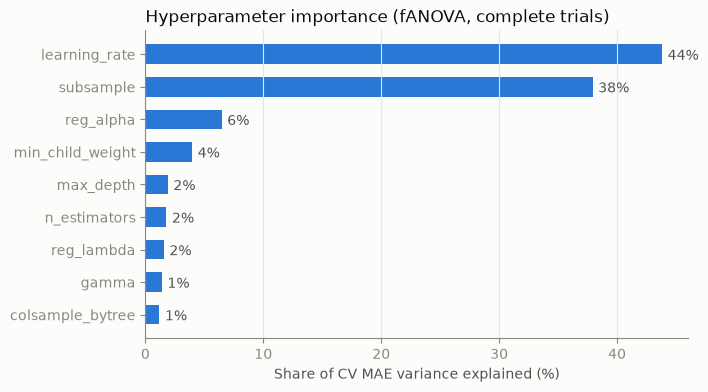

In [6]:
imp = optuna.importance.get_param_importances(
    study, evaluator=optuna.importance.FanovaImportanceEvaluator(seed=42)
)
imp = pd.Series(imp).sort_values()
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(imp.index, imp.values * 100, color=C_OM, height=0.6)
for y, v in enumerate(imp.values * 100):
    ax.annotate(f"{v:.0f}%", (v, y), textcoords="offset points", xytext=(4, -4), color=INK2)
ax.set_xlabel("Share of CV MAE variance explained (%)")
ax.set_title("Hyperparameter importance (fANOVA, complete trials)", loc="left")
ax.grid(axis="y", visible=False)
save(fig, "optuna_importance.png")

## 4. ผลบน dev 2024 (multi-output, train 2023) — ⚠️ optimistic

params ชุดเดียวกันใช้กับทั้ง 3 target (CMF_UVI / CMF_A / CMF_B)

In [7]:
dev.round(3)

,params,uvi_mae,uvi_rmse,uvi_r2,uvi_bias,recall_Very high,recall_Extreme,uva_mae_wm2,uvb_mae_wm2
0,default (v1),0.461,0.720,0.942,0.051,0.796,0.113,2.934,0.086
1,tuned,0.450,0.706,0.945,0.062,0.813,0.113,2.871,0.084


In [8]:
cv_tuned_path = docs / "cv_folds_2023_2024_tuned.csv"
if cv_tuned_path.exists():
    cv_old = pd.read_csv(docs / "cv_folds_2023_2024.csv")
    cv_new = pd.read_csv(cv_tuned_path)
    keys = ["uvi_mae", "recall_Very high", "recall_Extreme", "uva_mae_wm2", "uvb_mae_wm2"]
    comp = pd.concat({"v1 default": cv_old.set_index("fold")[keys],
                      "v2 tuned": cv_new.set_index("fold")[keys]}, axis=1)
    display(comp.round(3))
    display(pd.DataFrame({"v1 default": cv_old[keys].mean(), "v2 tuned": cv_new[keys].mean()}).round(3))
else:
    print("params not accepted -> no v2 model; cmf_multi_xgb_v1 remains current")

v1 default                                                          \
        uvi_mae recall_Very high recall_Extreme uva_mae_wm2 uvb_mae_wm2   
fold                                                                      
1         0.507            0.762          0.412       3.196       0.095   
2         0.585            0.388          0.333       3.222       0.097   
3         0.454            0.803          0.038       2.802       0.085   
4         0.537            0.799          0.200       3.408       0.100   
5         0.383            0.786          0.000       2.611       0.072   

     v2 tuned                                                          
      uvi_mae recall_Very high recall_Extreme uva_mae_wm2 uvb_mae_wm2  
fold                                                                   
1       0.501            0.773          0.235       3.216       0.100  
2       0.509            0.435          0.333       2.955       0.087  
3       0.446            0.811          0.038       2.738       0.083  
4       0.522            0.812          0.200       3.284       0.097  
5       0.371            0.798          0.000       2.528       0.069

,v1 default,v2 tuned
uvi_mae,0.493,0.470
recall_Very high,0.708,0.726
recall_Extreme,0.197,0.161
uva_mae_wm2,3.048,2.944
uvb_mae_wm2,0.090,0.087


## สรุป

- **100 trials** (complete 42 / pruned 58) trial ที่ดีที่สุดคือ **#50** ได้ CV MAE (fold 3–5) **0.4466** เทียบกับ params เดิม 0.4579 → ดีขึ้น **0.0113 UVI** ส่วน recall ระดับเตือนเฉลี่ย 0.443 เทียบกับ 0.438 (ไม่ลดลง) → **ผ่านกฎรับ params ทั้งสองข้อ แต่ผ่านแบบเฉียดฉิว** (เกณฑ์คือ > 0.01)
- **เจอที่ราบ:** trial 10 อันดับแรกห่างกันไม่ถึง 0.001 UVI หลายชุด params ให้ผลเท่ากัน การ tune จึงช่วยได้น้อย และ XGBoost น่าจะใกล้เพดานของ feature ชุดนี้แล้ว
- **Best params:** `learning_rate` 0.011, `n_estimators` 850, `max_depth` 10, `min_child_weight` 8.8, `subsample` 0.88, `colsample_bytree` 0.52 และ regularisation (`reg_lambda`, `reg_alpha`, `gamma`) ใกล้ 0 ความสำคัญตาม fANOVA: `learning_rate` 44 %, `subsample` 38 % ที่เหลือแต่ละตัวไม่เกิน 6 % ⚠️ **`learning_rate` ชนขอบล่างของ search space** (0.01; trial 10 อันดับแรกอยู่ที่ 0.010–0.025) และ `max_depth` = 10 ชนขอบบน (สำคัญแค่ 2 %) การขยายช่วงอาจช่วยได้อีกเล็กน้อย แต่จะไม่ขยายตอนนี้ เพราะ search space ประกาศไว้ก่อนรันแล้ว และที่ราบข้างบนบอกว่าส่วนที่ได้เพิ่มน่าจะเล็กกว่า noise
- **Multi-output บน dev 2024 (⚠️ optimistic):** UVI MAE 0.461 → **0.450**, R² 0.945, UVA 2.93 → 2.87 W/m², UVB 0.086 → 0.084 W/m², recall สูงมาก 0.80 → 0.81, รุนแรงมาก 0.11 (เท่าเดิม)
- **CV 5 folds:** UVI MAE 0.493 → **0.470**, UVA 3.05 → 2.94 W/m², UVB 0.090 → 0.087 W/m² แต่ recall ระดับรุนแรงมากเฉลี่ย 0.20 → 0.16 (fold 1: 0.41 → 0.24) → **การ tune ไม่ได้แก้ปัญหาระดับรุนแรงมาก** ต้องเตือนด้วย q90 ในวัน 9 ตามเดิม
- บันทึกเป็น `cmf_multi_xgb_v2.joblib` (params ชุดเดียวกันทั้ง 3 target) ส่วน v1 ยังเก็บไว้เทียบ
- ⚠️ ตัวเลข dev 2024 ข้างบนมี optimistic bias เพราะ fold 3–5 ที่ใช้ tune อยู่ในปี 2024 ตัวเลขจริงคือ **test 2025 ในวัน 10**